### process_sentiment1.ipynb

In this script, we will begin processing mood sentiment for songs we have. For 27 emotions (then we will look at the most common/most variable emotions.)

In [1]:
import os 
import numpy as np 
import pandas as pd 
import csv
import matplotlib.pyplot as plt 
import seaborn as sns
import random 
sns.set(rc={'figure.figsize':(15, 8)})

from glob import glob
from gensim.models import Word2Vec
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline # import NLP architecture
from scipy.sparse import dok_matrix
from sklearn.metrics.pairwise import cosine_similarity

%autosave 300

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Autosaving every 300 seconds


In [2]:
# Set up our directories 
currPath = os.getcwd()
playlistPath = os.path.abspath(os.path.join(currPath, os.pardir, 'data/playlist_subset'))
dataPath = os.path.join(playlistPath, 'lyrics')
lyrics_df = pd.read_csv(glob(os.path.join(dataPath, 'all_lyrics*'))[0])
lyrics_df = lyrics_df.drop(columns=['Unnamed: 0']) # get rid of unnecessary columns

# Also, set up our emotion classifier (from hugging face)
tokenizer = AutoTokenizer.from_pretrained("SamLowe/roberta-base-go_emotions")
model = AutoModelForSequenceClassification.from_pretrained("SamLowe/roberta-base-go_emotions")
emotion_classifier = pipeline("text-classification", model=model, truncation=True, tokenizer=tokenizer, max_length=512, return_all_scores=True)

Device set to use mps:0
/Users/arlene/opt/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/transformers/pipelines/text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


#### Get the sentiments for all the lyrics

In [3]:
# # For each song....
# for song in lyrics_df.index.values[:3]: 
#     # Get the lyrics for this song
#     curr_lyrics = lyrics_df.loc[song, 'lyrics']
#     lyric_moods = emotion_classifier(curr_lyrics)[0]

#     # Then, save it to a dataframe and save the output
#     mood_master = []
#     for l in lyric_moods: 
#         mood_name = list(l.values())[0]
#         mood_score = list(l.values())[1]
#         mood_df = pd.DataFrame([mood_score], index=[mood_name]).T
#         mood_master.append(mood_df)

#     # Then, concatenate the output and add to our dataframe 
#     mood_master = pd.concat(mood_master, axis=1)

#     # And finally, save the row to a new csv
#     csv_row = pd.concat([pd.DataFrame(lyrics_df.loc[song]).T.reset_index(drop=True), mood_master], axis=1)
#     with open(os.path.join(dataPath, 'lyrics_27_goemotions.csv'), "a", newline='') as this_file:
#         writer = csv.writer(this_file, quoting=csv.QUOTE_MINIMAL)

#         # Add headers if we are on the first row
#         if song == 0:
#             writer.writerow(csv_row.columns)

#         # Add the data row
#         writer.writerow(csv_row.values.flatten().tolist())

In [4]:
# Load in the lyrics sentiment
emo_df = glob(os.path.join(dataPath, 'emo/*27*.csv')); assert len(emo_df) == 1
emo_df = pd.read_csv(emo_df[0])

# Remove the instrumental songs 
instr_percent = len(emo_df[emo_df['lyrics'] == 'Instrumental']) / len(emo_df); instr_percent = instr_percent * 100 
print("Portion of Instrumental songs we are excluding: %s%%" % round(instr_percent, 2))

# Get rid of the instrumental songs
emo_df = emo_df[emo_df['lyrics'] != 'Instrumental']

Portion of Instrumental songs we are excluding: 0.89%


In [5]:
# First, determine which emotions are the most common out of 27
# Define the columns we want to deal with
emo_cols = emo_df.columns[-28:]

meta_col = [] # create df for mean/variance/product
for x in emo_cols: 
    # Get the mean, variance and product of this column
    curr_col = emo_df[x]
    col_mean = np.average(curr_col); col_var = np.var(curr_col)

    col_df = pd.DataFrame([x, col_mean, col_var, col_mean*col_var], index=['emotion', 'mean', 'var', 'product']).T
    meta_col.append(col_df)

meta_col = pd.concat(meta_col)

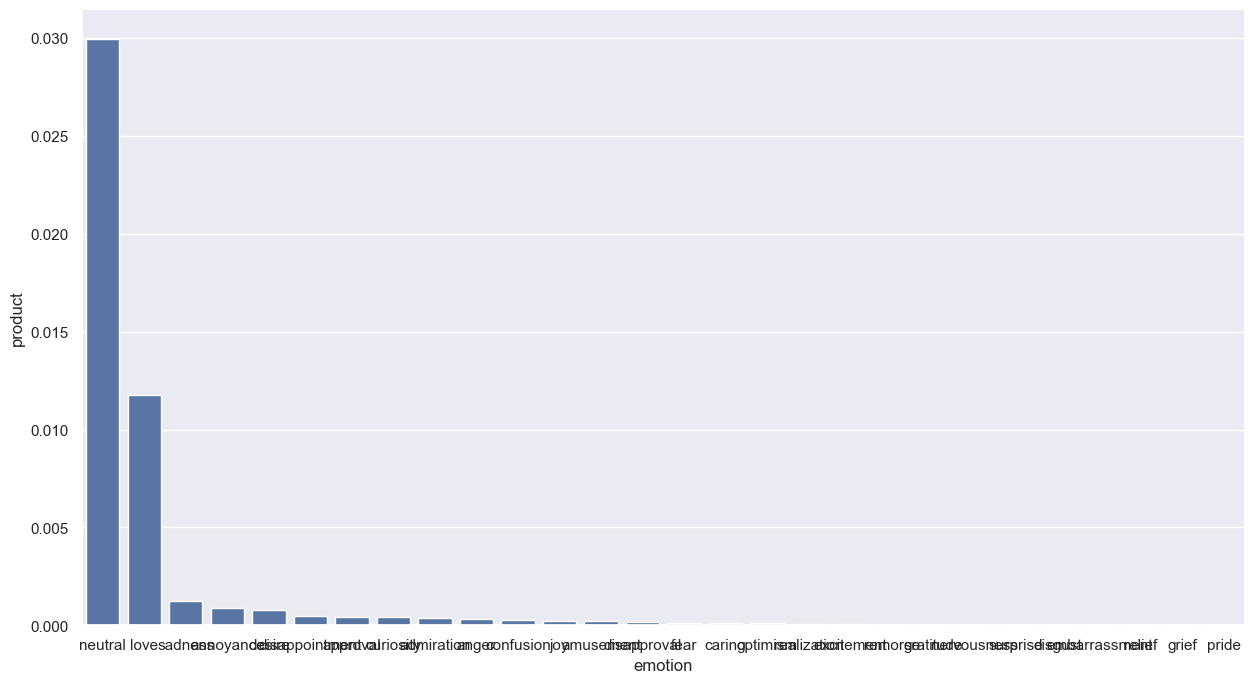

In [6]:
# Then, sort emotions by ascending to get the top ones 
meta_col = meta_col.sort_values(by='product',ascending = False)
meta_col.reset_index(drop=True, inplace=True)

# Plot the product to see what everything looks like
sns.barplot(meta_col, x="emotion", y="product")
# plt.show()

# Finally, choose the top 10 emotions (by removing the emotions we don't need)
emo_df = emo_df.drop(columns = meta_col[10:]['emotion'].values)


<Axes: xlabel='emotion', ylabel='mean'>

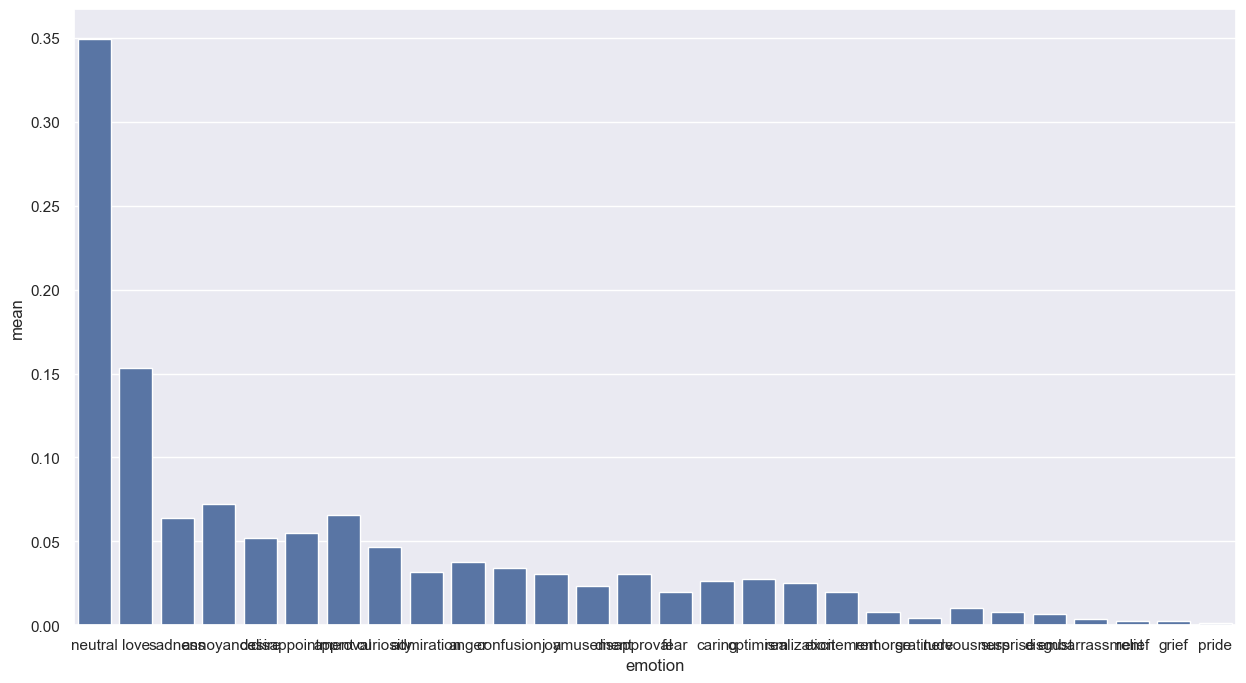

In [7]:
# Plot the mean to see what everything looks like
sns.barplot(meta_col, x="emotion", y="mean")
# plt.show()

<Axes: xlabel='emotion', ylabel='var'>

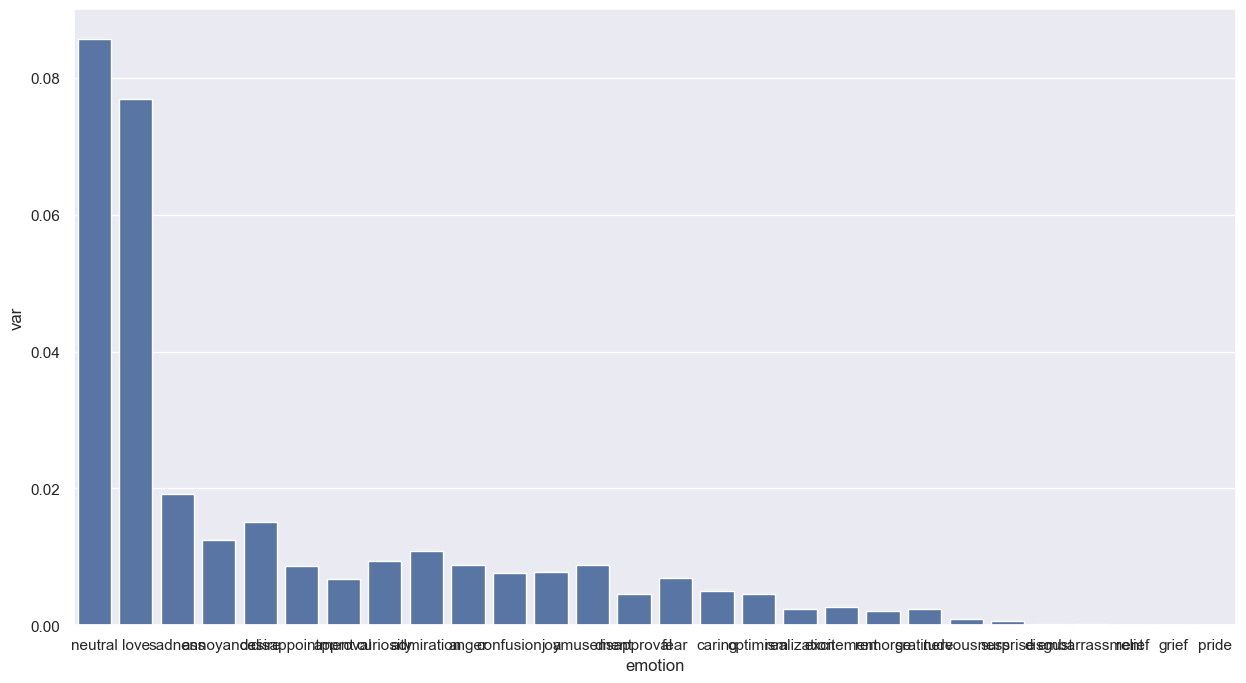

In [139]:
# Plot the variance to see what everything looks like
sns.barplot(meta_col, x="emotion", y="var")
# plt.show()

#### Start building model


In [8]:
# Import the playlists we will use
playlist_files = [x for x in os.listdir(os.path.join(playlistPath)) if x.startswith('playlist_subset') if 'test' not in x if not x.endswith('_4.csv.gz')]
assert len(playlist_files) == 4

# Create dataframe for all of our playlist data
playlist_train = []
for p in playlist_files: 
    curr_playlist_file = pd.read_csv(os.path.join(playlistPath, p))
    playlist_train.append(curr_playlist_file)

# Initalize this dataframe 
playlist_train = pd.concat(playlist_train)

In [107]:
# Merge the dataset with lyrics
emo_df_final = emo_df.drop(columns=emo_df.columns[1:9])
playlist_merged = playlist_train.merge(emo_df_final, on='track_uri', how='left')

# Make sure the merged df is the same length as the original playlist_train df
assert len(playlist_merged) == len(playlist_train)

# Then, extract all songs that we have lyrics for ONLY 
playlist_merged = playlist_merged[playlist_merged['found_tag'] == '1']

#### Then, get the co-occurrence for all songs (across playlists)

In [10]:
# Create the co-occurrence matrix across all unique songs
n_songs = len(np.unique(playlist_merged['track_uri']))
n_playlists = len(np.unique(playlist_merged['pid']))
co_ocurr_mat = dok_matrix((n_songs, n_playlists), dtype=np.int8) # setting up the sparse mat 

# Then, come up with 'locations' for each song/playlist in our eventual matrix
song_idx = {uri: i for i, uri in enumerate(playlist_merged["track_uri"].unique())}
playlist_idx = {pid: i for i, pid in enumerate(playlist_merged["pid"].unique())}

In [8]:
# Convert the playlist data into a dict (to cycle through later)
playlist_dict = (playlist_merged.groupby('pid')['track_uri'].apply(list).to_dict())

# For each dict key (playlist) and value (track)
for pid, uri in playlist_dict.items(): 
    # For this current playlist, then cycle through the songs... 
    for curr_uri in uri: 
        mat_row = song_idx[curr_uri] # rows will be the songs
        mat_col = playlist_idx[pid] # columns will be the playlists
        co_ocurr_mat[mat_row, mat_col] = 1 # add a 1 b/c the current song is in the current playlist...

KeyboardInterrupt: 

In [17]:
# Save our sparse matrix for later use (just in case)
from scipy import sparse
# co_ocurr_mat_sparse = co_ocurr_mat.tocsr()
# sparse.save_npz(os.path.join(playlistPath, 'mats/cooccur_train_matrix.npz'), co_ocurr_mat_sparse)

# Load in our sparse matrix 
co_occur_mat_sparse = sparse.load_npz(os.path.join(playlistPath, 'mats/cooccur_train_matrix.npz')) 
co_occur_mat_sparse = co_occur_mat_sparse.toarray()

#### Initilalize prediction model

In [315]:
# Initialize functions
def get_playlist_vector(current_ids, coOccur_mat, not_in_playlist, sample_frac = .75): 
    """Returns a vector for 75% of a playlist"""

    # If the length of the current playlist is less than 20, then return nothing
    if len(current_ids) < 20: 
        return None

    # Get a mean vector for 75% of the playlists...
    sample_size = int(len(current_ids) * sample_frac)
    sampled = random.sample(current_ids, sample_size)

    ##################################### Computing coocurrence #####################################
    # Extract the vectors from our matrix 
    sampled_vec = []
    for s in sampled: 
        # Using the song index, extract the co-occurrence matrix
        song_vec = coOccur_mat[song_idx[s]]
        # song_vec = song_vec.flatten()
        sampled_vec.append(song_vec)
    
    # Then, get the row-wise means across all of these songs
    cooccur_avgAcross_samples = np.mean(sampled_vec, axis=0)

    # Then, the co-occurrence matrix for the 25% of the playlist
    percent_25 = [x for x in current_ids if x not in sampled] # 25% left out

    # Then, combine these songs with all other songs not in the playlist
    song_choices = percent_25 + not_in_playlist

    # Then, extract the indices for each song (to later get their co-occurrence vectors)
    select_song_idx = {song_idx[x] for x in song_choices if x in song_idx}
    song_choice_vecs = coOccur_mat[list(select_song_idx), :]
    # song_choice_vecs = song_choice_vecs.toarray() # get matrix of all songs  

    cooccur_similarities = cosine_similarity(song_choice_vecs, cooccur_avgAcross_samples.reshape(1, -1))

    # # Then, get the cosine similarity between each song choice and the averaged playlist vector
    # # Do it in batches because we have a lot of data
    # chunk_size = 10000
    # results = []

    # for i in range(0, song_choice_vecs.shape[0], chunk_size)[:1]:
    #     chunk = song_choice_vecs[i:i+chunk_size]
    #     sims = cosine_similarity(chunk, cooccur_avgAcross_samples.reshape(1, -1))
    #     results.append(sims)

    # similarities = np.vstack(results).flatten()

    ##################################### Computing lyrics similarity #####################################
    # First, get an average emotion vector for the 75% of the playlist we have
    emotion_75_mask = playlist_merged['track_uri'].isin(sampled) 
    emotion_75 = playlist_merged.loc[emotion_75_mask]
    emotion_75 = emotion_75.drop_duplicates(subset='track_uri')
    assert len(emotion_75) == len(sampled) # make sure that we have the correct number of songs

    emotion_75_vals = emotion_75.iloc[:, -10:].values # then, get the row-wise means across all of these songs
    emotion_75_acrossAvg = np.mean(emotion_75_vals, axis=0)

    # Also, get the emotion vectors of every other song (including the 25 percent of the playlist we don't have)
    all_other_mask = playlist_merged['track_uri'].isin(song_choices) 
    all_other_df = playlist_merged.loc[all_other_mask]
    all_other_df = all_other_df.drop_duplicates(subset='track_uri')
    assert len(all_other_df) == len(song_choices) # make sure we have the correct number of songs
    all_others_vals = all_other_df.iloc[:, -10:].values # get all of the vectors

    # Get the cosine similarity between the averaged emotion vector and all other vector
    emo_similarities = cosine_similarity(all_others_vals, emotion_75_acrossAvg.reshape(1, -1))

    ##################################### Obtain top 5 #####################################
    # First, get the joint cooccurrence and emo similarity (weigh them each as .5)
    co_sim_weighted = cooccur_similarities * .5; emo_sim_weighted = emo_similarities * .5
    joint_sim = emo_sim_weighted + co_sim_weighted

    # Then, choose the top 5 joint similarity
    n_most_sim = 5
    idx_most_sim = np.argsort(joint_sim.flatten())[-n_most_sim:][::-1]  

    # Then, convert these into track ids 
    most_sim_trackIds = [song_choices[i] for i in idx_most_sim]

    # Then, check whether this song is in our 25% of playlist
    hit_counter = 0 
    for x in most_sim_trackIds: 
        if x in percent_25: 
            hit_counter += 1

    # Determine whether we got any guesses correct
    if hit_counter > 0: 
        hit_any = 1
    else: 
        hit_any = 0

    ##################################### Additional metadata #####################################
    # Get the dominant mood of the playlist (75%)
    dom_mood = np.argsort(emotion_75_acrossAvg.flatten())[-1:][0]
    dom_mood = emo_list[dom_mood]

    # Also, get the cosine similarity values between the 75% and the heldout data
    heldout_ids = [x for x in song_choices if x in percent_25]
    heldout_idx = [song_choices.index(x) for x in heldout_ids] 
    heldout_sim = joint_sim[heldout_idx]

    # Get the cosine similarity values between 75% and completely NOVEL songs (same length of heldout)
    not_heldout_ids = [x for x in song_choices if not x in percent_25]
    not_heldout_idx = [song_choices.index(x) for x in not_heldout_ids] 
    not_heldout_sim = joint_sim[not_heldout_idx]
    not_heldout_top = np.argsort(not_heldout_sim.flatten())[-len(percent_25):][::-1] # get top sims of heldout length
    not_heldout_top_sim = not_heldout_sim[not_heldout_top]

    # Finally, get cosine similarity values between 75% and random songs (same length of heldout)
    random_sims = random.sample(list(joint_sim.flatten()), len(percent_25))

    ##################################### Put info into an array #####################################
    output_info = {
    "hit_any": hit_any,
    "hit_counter": hit_counter,
    "most_sim_trackIds": most_sim_trackIds,
    "percent_25": percent_25,
    "sampled": sampled,
    "dom_mood": dom_mood,
    "heldout_sim": heldout_sim,
    "not_heldout_top_sim": not_heldout_top_sim,
    "random_sims": random_sims,
}

    return output_info # most_sim_trackIds, song_choices

        

In [316]:
# For each playlist... 
all_pids = playlist_merged[playlist_merged['pos'] == 0]['pid'].values # get all training pids

# Gather the hits

# Also, gather the percentage of hits


for p in all_pids[:1]:
    # Extract each song in the current playlist 
    curr_playlist_df = playlist_merged[playlist_merged['pid'] == p]
    curr_playlist_uri = np.unique(curr_playlist_df['track_uri'].values) # unique just in case there are duplicates within a playlist

    # Define the list of emotions we are dealing with
    emo_list = curr_playlist_df.iloc[:, -10:].columns

    # Also, extract every other song that is not in the playlist
    other_songs = playlist_merged[playlist_merged['pid'] != p]
    other_mask = ~other_songs['track_uri'].isin(curr_playlist_uri) # figure out which songs are not in the current playlist
    other_songs = list(np.unique(other_songs.loc[other_mask, 'track_uri']))
    
    # track_ids, sims, actual_play_songs  = get_playlist_vector(list(curr_playlist_uri), co_occur_mat_sparse, other_songs)
    output_dict = get_playlist_vector(list(curr_playlist_uri), co_occur_mat_sparse, other_songs)

    # Then, add in the length of the playlist to this array of values
    add_data = {"len_playlist": len(curr_playlist_df), "playlist_id": p}
    output_dict.update(add_data) # updates our dictionary in place

    


        

In [323]:
# Then, just gather the hits and the percentage of hits made for each playlist
output_dict['hit_any']

1

In [321]:
# also, write out this information into a csv that we update incrementally...
output_dict['hit_any']

{'hit_any': 1,
 'hit_counter': 2,
 'most_sim_trackIds': ['spotify:track:0725YWm6Z0TpZ6wrNk64Eb',
  'spotify:track:15VRO9CQwMpbqUYA7e6Hwg',
  'spotify:track:3eze1OsZ1rqeXkKStNfTmi',
  'spotify:track:03RFScByLwJTxTme6n4BpP',
  'spotify:track:0cyDtn3bMS1XoTp6Lcef1d'],
 'percent_25': ['spotify:track:0725YWm6Z0TpZ6wrNk64Eb',
  'spotify:track:0L7loeTIg6akW84aEQZpCT',
  'spotify:track:0WCbhE2evMrIwRM0DlMy9k',
  'spotify:track:0YpBHgZ9Pfr4fbiKkP9nj9',
  'spotify:track:0v9Wz8o0BT8DU38R4ddjeH',
  'spotify:track:0ytw2owVvegkIS87txqV1O',
  'spotify:track:10I3CmmwT0BkOVhduDy53o',
  'spotify:track:1fOkmYW3ZFkkjIdOZSf596',
  'spotify:track:2eqUZAVXjK61mZqLl4LKJJ',
  'spotify:track:3ESSGgWzRf1xvP7G5hHMhB',
  'spotify:track:3MnbXlC1N7GdS9M8HzA6no',
  'spotify:track:3NJG6vMH1ZsectZkocMEm0',
  'spotify:track:3aJkV6DUTSCqOwVwaBDG9B',
  'spotify:track:3eze1OsZ1rqeXkKStNfTmi',
  'spotify:track:3iVcZ5G6tvkXZkZKlMpIUs',
  'spotify:track:432hUIl3ISDeytYW5XBQ5h',
  'spotify:track:4SYUUlkScpNR1QvPscXf8t',
  'spo

In [ ]:
playlist_id, any_hit, num_hit, tracks_guessed, tracks_heldout, tracks_train, dom_mood, length of the playlist, # later: generalization similarity, 
sim_heldout, sim_gen, sim_random

In [ ]:
dataframe 
playlist_id, any_hit, num_hit, tracks_guessed, tracks_heldout, tracks_train, dom_mood, length of the playlist, # later: generalization similarity, 
sim_heldout, sim_gen, sim_random

In [ ]:
# however. the thing that we need is... we need to calculate the most similar co-occurrence

# so why don't we calculate the matrix first? wait. hmm. yes, we will need to do that because 
# we will then, out of ALL remaining songs (left out + other songs, we will choose the most similar)
# and then see whether we have a hit. this is how many songs we got correct. and we will choose this according
# to which song has the highest cosine similarity according to the average cosine similarity...

In [ ]:
# I think we need to come up with the order of the playlists, and make sure its the same throughout... 


In [ ]:
# Get the co-occurrence vector for each 

In [ ]:
        p1 p2 p3
song a  1  0  1
song b  1  1  1

In [249]:
for p in playlist_files: 
    curr_playlist_file = pd.read_csv(os.path.join(playlistPath, p))

    n_playlists = len(np.unique(curr_playlist_file['pid'].values))

    print(n_playlists)

5000
1000
5000
5000
